# Import Libraries & Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

df = pd.read_csv('moe_layer_memory_log_20250720_180411.csv')
df.head()
n_samples = df.shape[0]

In [4]:
df.columns

Index(['timestamp', 'batch_id', 'moe_layer_id', 'experts_activated',
       'GPU_0_total_mem_capacity', 'GPU_0_mem_usage', 'GPU_0_mem_free',
       'GPU_0_experts_can_fit', 'GPU_1_total_mem_capacity', 'GPU_1_mem_usage',
       'GPU_1_mem_free', 'GPU_1_experts_can_fit'],
      dtype='object')

# Mean GPU Memory Free Per Microbatch #

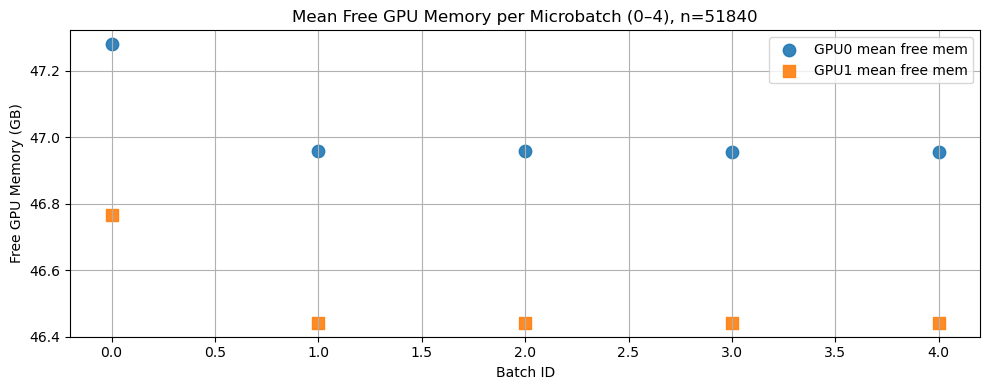

In [16]:
# 1) — one dot per batch (mean across layers)
batch_stats = (
    df
    .groupby('batch_id')[['GPU_0_mem_free', 'GPU_1_mem_free']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
plt.scatter(batch_stats['batch_id'],
            batch_stats['GPU_0_mem_free'],
            s=80, marker='o', alpha=0.9,
            label='GPU0 mean free mem')
plt.scatter(batch_stats['batch_id'],
            batch_stats['GPU_1_mem_free'],
            s=80, marker='s', alpha=0.9,
            label='GPU1 mean free mem')
plt.xlabel('Batch ID')
plt.ylabel('Free GPU Memory (GB)')
plt.title(f'Mean Free GPU Memory per Microbatch (0–4), n={n_samples}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mean GPU Memory Free per MoE Layer

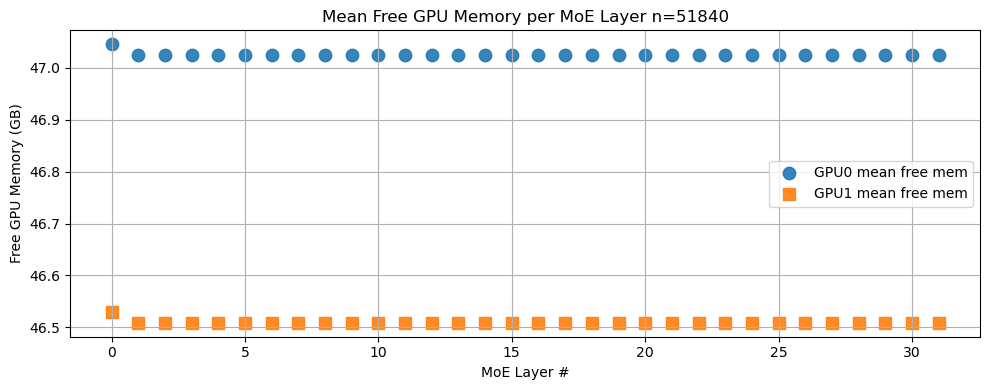

In [17]:
# 1) — one dot per batch (mean across layers)
batch_stats = (
    df
    .groupby('moe_layer_id')[['GPU_0_mem_free', 'GPU_1_mem_free']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
plt.scatter(batch_stats['moe_layer_id'],
            batch_stats['GPU_0_mem_free'],
            s=80, marker='o', alpha=0.9,
            label='GPU0 mean free mem')
plt.scatter(batch_stats['moe_layer_id'],
            batch_stats['GPU_1_mem_free'],
            s=80, marker='s', alpha=0.9,
            label='GPU1 mean free mem')
plt.xlabel('MoE Layer #')
plt.ylabel('Free GPU Memory (GB)')
plt.title(f'Mean Free GPU Memory per MoE Layer n={n_samples}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extra Experts that Can Fit Per Microbatch

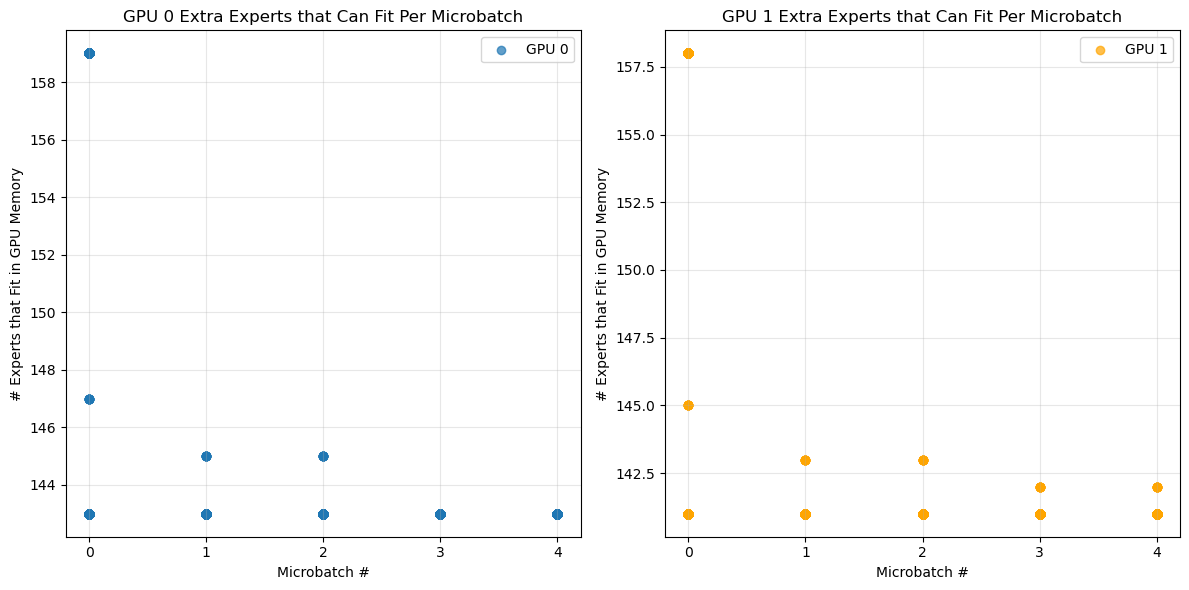

In [15]:
plt.figure(figsize=(12, 6))

# Plot GPU 0 free memory
plt.subplot(1, 2, 1)
plt.scatter(df['batch_id'], df['GPU_0_experts_can_fit'], alpha=0.7, label='GPU 0')
plt.xlabel('Microbatch #')
plt.ylabel('# Experts that Fit in GPU Memory')
plt.title('GPU 0 Extra Experts that Can Fit Per Microbatch')
plt.grid(True, alpha=0.3)
plt.legend()

# Set integer intervals for x-axis
max_batch = df['batch_id'].max()
plt.xticks(range(0, int(max_batch) + 1))

# Plot GPU 1 free memory
plt.subplot(1, 2, 2)
plt.scatter(df['batch_id'], df['GPU_1_experts_can_fit'], alpha=0.7, color='orange', label='GPU 1')
plt.xlabel('Microbatch #')
plt.ylabel('# Experts that Fit in GPU Memory')
plt.title('GPU 1 Extra Experts that Can Fit Per Microbatch')
plt.grid(True, alpha=0.3)
plt.legend()

# Set integer intervals for x-axis
plt.xticks(range(0, int(max_batch) + 1))

plt.tight_layout()
plt.show()

# Extra Experts that Can Fit Per MoE Layer

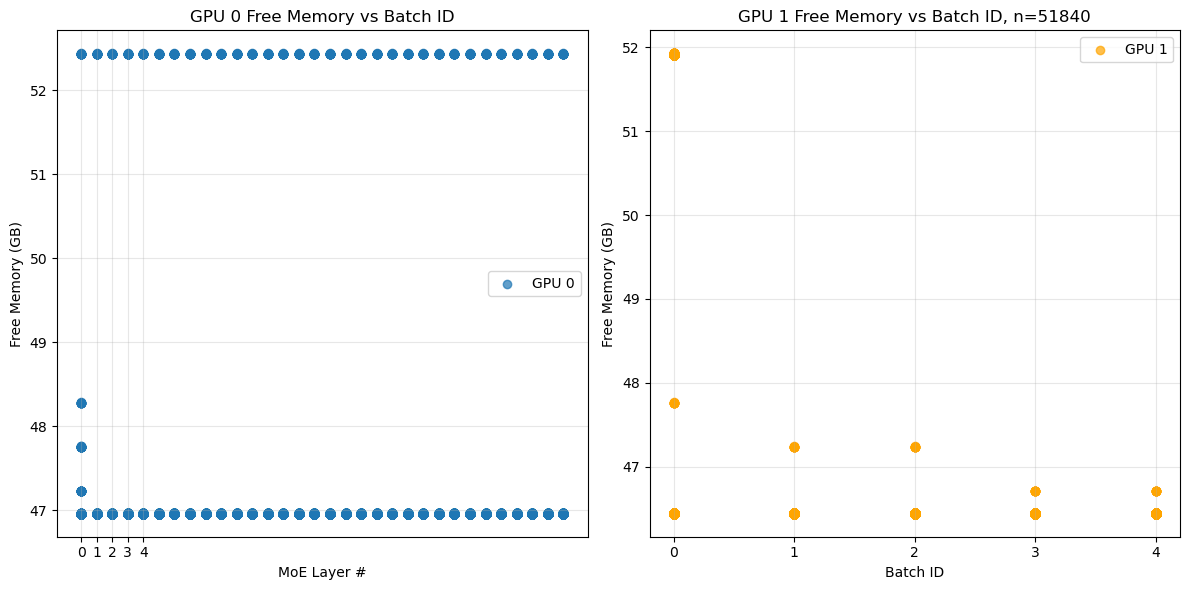

# Extra Experts that Can Fit Per MoE Layer

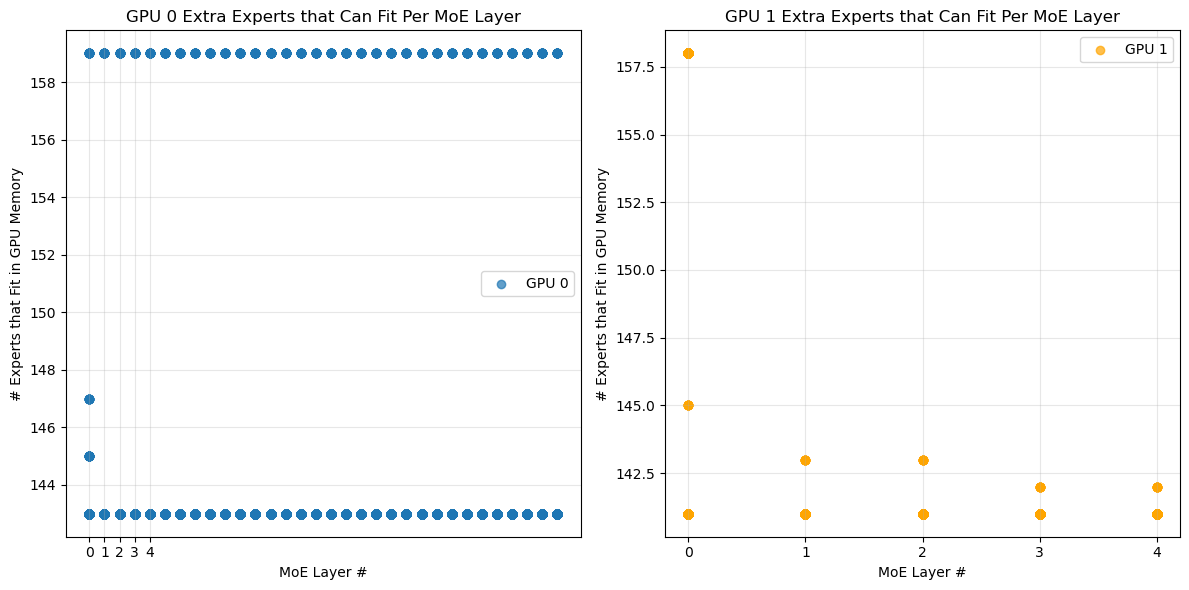

In [22]:
plt.figure(figsize=(12, 6))

# Plot GPU 0 free memory
plt.subplot(1, 2, 1)
plt.scatter(df['moe_layer_id'], df['GPU_0_experts_can_fit'], alpha=0.7, label='GPU 0')
plt.xlabel('MoE Layer #')
plt.ylabel('# Experts that Fit in GPU Memory')
plt.title('GPU 0 Extra Experts that Can Fit Per MoE Layer')
plt.grid(True, alpha=0.3)
plt.legend()

# Set integer intervals for x-axis
max_batch = df['batch_id'].max()
plt.xticks(range(0, int(max_batch) + 1))

# Plot GPU 1 free memory
plt.subplot(1, 2, 2)
plt.scatter(df['batch_id'], df['GPU_1_experts_can_fit'], alpha=0.7, color='orange', label='GPU 1')
plt.xlabel('MoE Layer #')
plt.ylabel('# Experts that Fit in GPU Memory')
plt.title('GPU 1 Extra Experts that Can Fit Per MoE Layer')
plt.grid(True, alpha=0.3)
plt.legend()

# Set integer intervals for x-axis
plt.xticks(range(0, int(max_batch) + 1))

plt.tight_layout()
plt.show()

# Expert Activations

In [25]:
df['num_activated'] = df['experts_activated'].apply(lambda s: len(eval(s)))
total = len(df)
full_count = (df['num_activated'] == 8).sum()
partial_count = total - full_count
full_pct = full_count / total * 100

partial = df[df['num_activated'] < 8]

from collections import Counter
cnts = Counter(e for lst in partial['experts_activated'].map(eval) for e in lst)

# Pie Charts Showing % < N Expert Activations Per Microbatch

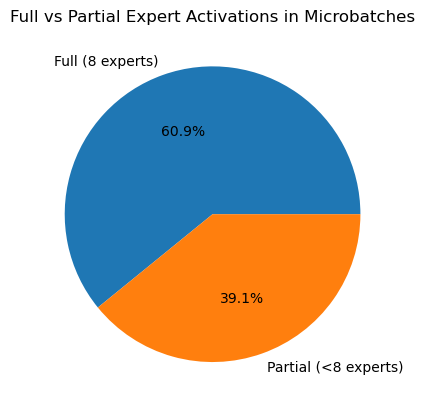

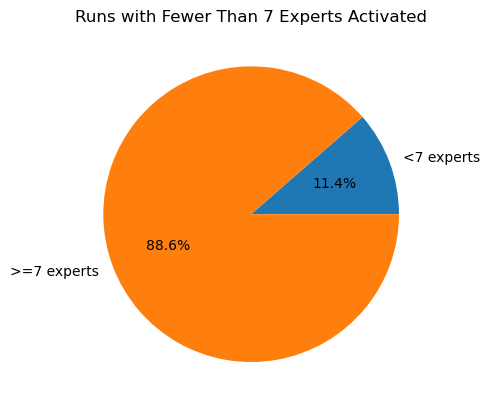

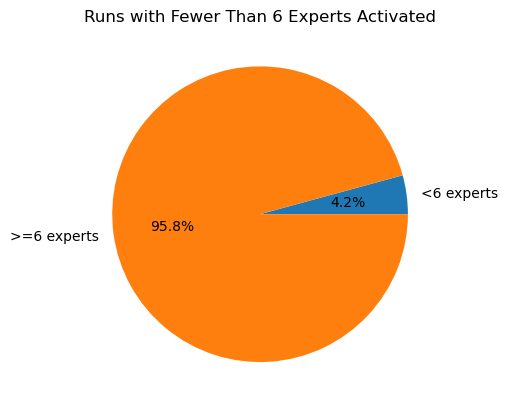

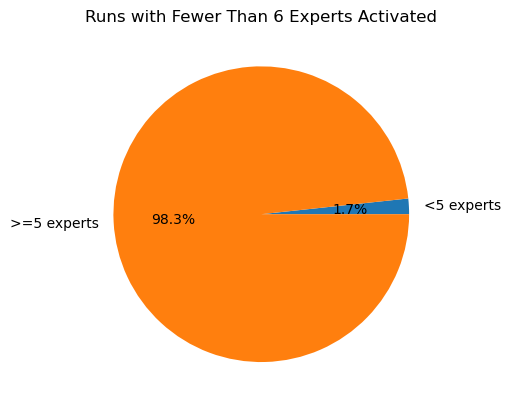

In [31]:
df['num_activated'] = df['experts_activated'].apply(lambda s: len(eval(s)))
total = len(df)
full_count = (df['num_activated'] == 8).sum()
partial_count = total - full_count

# Pie chart: full vs partial
plt.figure()
plt.pie([full_count, partial_count], labels=['Full (8 experts)', 'Partial (<8 experts)'], autopct='%1.1f%%')
plt.title('Full vs Partial Expert Activations in Microbatches')
plt.show()

# Pie chart: <7 vs >=7
lt7_count = (df['num_activated'] < 7).sum()
ge7_count = total - lt7_count
plt.figure()
plt.pie([lt7_count, ge7_count], labels=['<7 experts', '>=7 experts'], autopct='%1.1f%%')
plt.title('Runs with Fewer Than 7 Experts Activated')
plt.show()

# Pie chart: <6 vs >=6
lt6_count = (df['num_activated'] < 6).sum()
ge6_count = total - lt6_count
plt.figure()
plt.pie([lt6_count, ge6_count], labels=['<6 experts', '>=6 experts'], autopct='%1.1f%%')
plt.title('Runs with Fewer Than 6 Experts Activated')
plt.show()

# Pie chart: <5 vs >=5
lt6_count = (df['num_activated'] < 5).sum()
ge6_count = total - lt6_count
plt.figure()
plt.pie([lt6_count, ge6_count], labels=['<5 experts', '>=5 experts'], autopct='%1.1f%%')
plt.title('Runs with Fewer Than 6 Experts Activated')
plt.show()

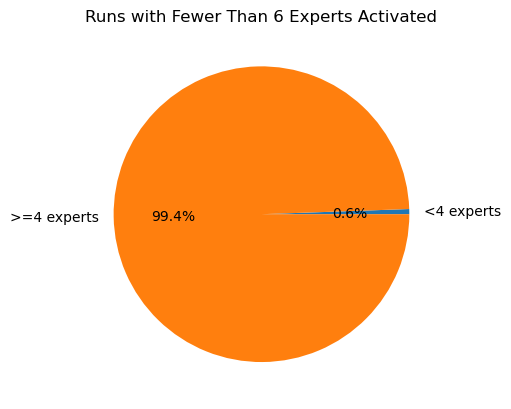

In [32]:
# Pie chart: <4 vs >=4
lt6_count = (df['num_activated'] < 4).sum()
ge6_count = total - lt6_count
plt.figure()
plt.pie([lt6_count, ge6_count], labels=['<4 experts', '>=4 experts'], autopct='%1.1f%%')
plt.title('Runs with Fewer Than 6 Experts Activated')
plt.show()

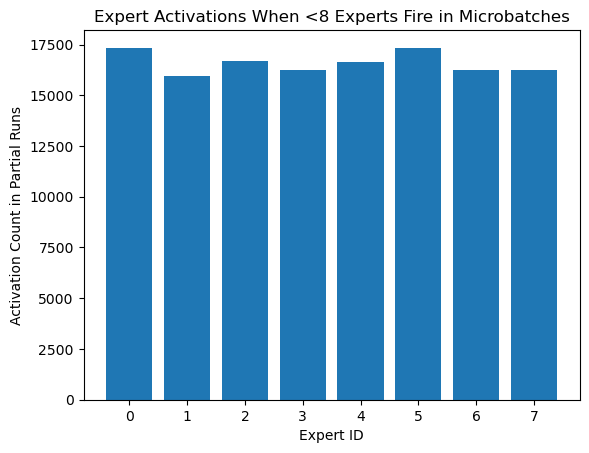

In [29]:
# Count activations in partial cases
partial = df[df['num_activated'] < 8]
cnts = Counter(e for lst in partial['experts_activated'].map(eval) for e in lst)

# Bar chart: expert activation frequencies in partial runs
plt.figure()
plt.bar(list(cnts.keys()), list(cnts.values()))
plt.xlabel('Expert ID')
plt.ylabel('Activation Count in Partial Runs')
plt.title('Expert Activations When <8 Experts Fire in Microbatches')
plt.show()